# Day 40/60 — Evaluating Business Decisions with A/B Testing

## A/B Testing Analytics

Using experimentation and statistical analysis to compare control
and experiment groups and evaluate business decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

print("Day 40 libraries imported successfully!")

Day 40 libraries imported successfully!


In [2]:
np.random.seed(42)

control_users = 1000
experiment_users = 1000

control_conversions = np.random.binomial(
    1,
    0.12,
    control_users
)

experiment_conversions = np.random.binomial(
    1,
    0.15,
    experiment_users
)

control_data = pd.DataFrame({
    "group": "Control",
    "converted": control_conversions
})

experiment_data = pd.DataFrame({
    "group": "Experiment",
    "converted": experiment_conversions
})

ab_data = pd.concat(
    [control_data, experiment_data],
    ignore_index=True
)

print("A/B testing dataset created successfully!")

print("\nDataset shape:")
print(ab_data.shape)

display(ab_data.head(10))

A/B testing dataset created successfully!

Dataset shape:
(2000, 2)


,group,converted
0,Control,0
1,Control,1
2,Control,0
3,Control,0
4,Control,0
5,Control,0
6,Control,0
7,Control,0
8,Control,0
9,Control,0


In [3]:
group_summary = (
    ab_data
    .groupby("group")
    .agg(
        users=("converted", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

group_summary["conversion_rate"] = (
    group_summary["conversions"]
    / group_summary["users"]
) * 100

print("A/B testing group summary created successfully!")

display(group_summary)

A/B testing group summary created successfully!


,group,users,conversions,conversion_rate
0,Control,1000,124,12.4
1,Experiment,1000,152,15.2


In [4]:
control_rate = (
    group_summary.loc[
        group_summary["group"] == "Control",
        "conversion_rate"
    ].iloc[0]
)

experiment_rate = (
    group_summary.loc[
        group_summary["group"] == "Experiment",
        "conversion_rate"
    ].iloc[0]
)

absolute_difference = experiment_rate - control_rate

relative_improvement = (
    absolute_difference / control_rate
) * 100

print("Conversion rate comparison completed successfully!")

print("\nControl conversion rate:")
print(round(control_rate, 2), "%")

print("\nExperiment conversion rate:")
print(round(experiment_rate, 2), "%")

print("\nAbsolute difference:")
print(round(absolute_difference, 2), "percentage points")

print("\nRelative improvement:")
print(round(relative_improvement, 2), "%")

Conversion rate comparison completed successfully!

Control conversion rate:
12.4 %

Experiment conversion rate:
15.2 %

Absolute difference:
2.8 percentage points

Relative improvement:
22.58 %


In [5]:
control_converted = group_summary.loc[
    group_summary["group"] == "Control",
    "conversions"
].iloc[0]

control_not_converted = (
    group_summary.loc[
        group_summary["group"] == "Control",
        "users"
    ].iloc[0]
    - control_converted
)

experiment_converted = group_summary.loc[
    group_summary["group"] == "Experiment",
    "conversions"
].iloc[0]

experiment_not_converted = (
    group_summary.loc[
        group_summary["group"] == "Experiment",
        "users"
    ].iloc[0]
    - experiment_converted
)

contingency_table = np.array([
    [control_converted, control_not_converted],
    [experiment_converted, experiment_not_converted]
])

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Statistical significance test completed successfully!")

print("\nChi-square statistic:")
print(round(chi2, 4))

print("\nP-value:")
print(round(p_value, 6))

Statistical significance test completed successfully!

Chi-square statistic:
3.0642

P-value:
0.080037


In [6]:
significance_level = 0.05

if p_value < significance_level:
    statistical_result = "Statistically Significant"
    business_decision = "The Experiment shows a meaningful improvement."
else:
    statistical_result = "Not Statistically Significant"
    business_decision = "There is not enough evidence to confirm an improvement."

print("A/B testing decision completed!")

print("\nStatistical Result:")
print(statistical_result)

print("\nBusiness Decision:")
print(business_decision)

print("\nSignificance Level:")
print(significance_level)

A/B testing decision completed!

Statistical Result:
Not Statistically Significant

Business Decision:
There is not enough evidence to confirm an improvement.

Significance Level:
0.05


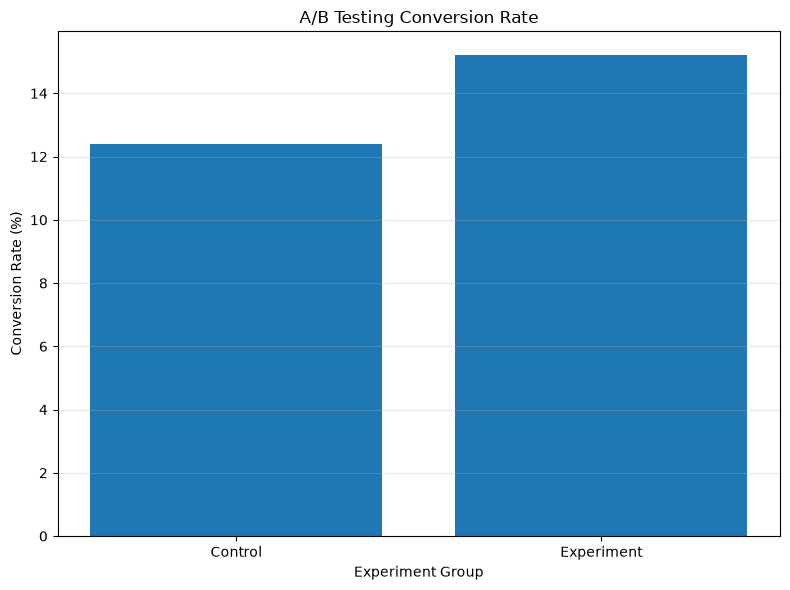

A/B testing conversion chart created successfully!


In [7]:
plt.figure(figsize=(8, 6))

plt.bar(
    group_summary["group"],
    group_summary["conversion_rate"]
)

plt.title("A/B Testing Conversion Rate")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("A/B testing conversion chart created successfully!")

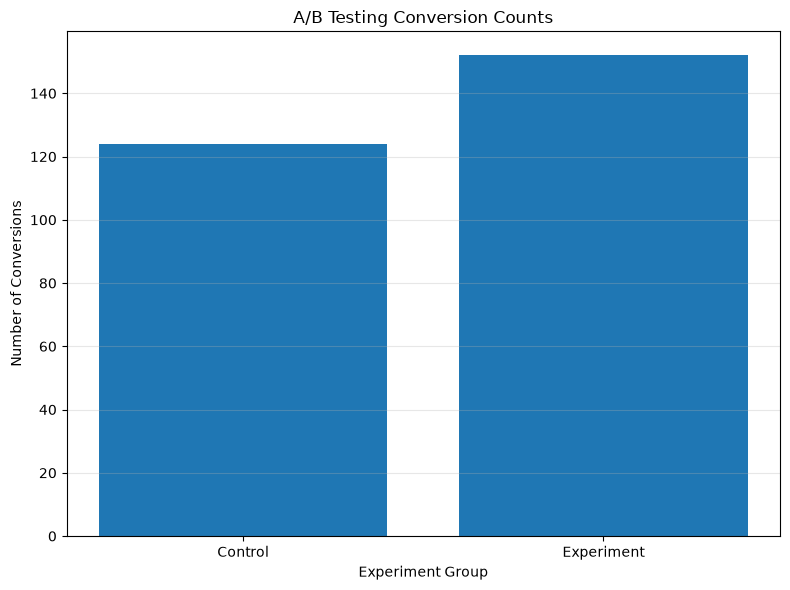

Conversion count chart created successfully!


In [8]:
plt.figure(figsize=(8, 6))

plt.bar(
    group_summary["group"],
    group_summary["conversions"]
)

plt.title("A/B Testing Conversion Counts")
plt.xlabel("Experiment Group")
plt.ylabel("Number of Conversions")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("Conversion count chart created successfully!")

In [9]:
experiment_summary = pd.DataFrame({
    "Metric": [
        "Control Conversion Rate",
        "Experiment Conversion Rate",
        "Absolute Difference",
        "Relative Improvement",
        "P-Value",
        "Significance Level",
        "Statistical Result"
    ],
    "Value": [
        round(control_rate, 2),
        round(experiment_rate, 2),
        round(absolute_difference, 2),
        round(relative_improvement, 2),
        round(p_value, 6),
        significance_level,
        statistical_result
    ]
})

print("A/B testing experiment summary created successfully!")

display(experiment_summary)

A/B testing experiment summary created successfully!


,Metric,Value
0,Control Conversion Rate,12.4
1,Experiment Conversion Rate,15.2
2,Absolute Difference,2.8
3,Relative Improvement,22.58
4,P-Value,0.080037
5,Significance Level,0.05
6,Statistical Result,Not Statistically Significant


In [10]:
if p_value < significance_level and experiment_rate > control_rate:
    recommendation = (
        "Roll out the Experiment because it shows a statistically "
        "significant improvement in conversion rate."
    )
elif p_value < significance_level and experiment_rate <= control_rate:
    recommendation = (
        "Keep the Control version because the Experiment does not "
        "provide a statistically significant improvement."
    )
else:
    recommendation = (
        "Do not make a final rollout decision yet. The experiment "
        "does not provide enough statistical evidence."
    )

print("Business recommendation generated successfully!")

print("\nRecommendation:")
print(recommendation)

Business recommendation generated successfully!

Recommendation:
Do not make a final rollout decision yet. The experiment does not provide enough statistical evidence.


In [11]:
group_summary.to_csv(
    "ab_group_summary.csv",
    index=False
)

experiment_summary.to_csv(
    "ab_experiment_summary.csv",
    index=False
)

with open(
    "business_recommendation.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(recommendation)

print("Day 40 A/B testing files saved successfully!")

print("\nCreated files:")
print("✓ ab_group_summary.csv")
print("✓ ab_experiment_summary.csv")
print("✓ business_recommendation.txt")

Day 40 A/B testing files saved successfully!

Created files:
✓ ab_group_summary.csv
✓ ab_experiment_summary.csv
✓ business_recommendation.txt


In [12]:
report = f"""
# Day 40 — A/B Testing Business Decision Report

## Experiment Overview

This project evaluates a simulated A/B testing experiment designed
to compare a Control version with an Experiment version.

The goal is to determine whether the Experiment improves conversion
performance.

## Experiment Groups

- Control Users: {control_users}
- Experiment Users: {experiment_users}

## Results

- Control Conversion Rate: {control_rate:.2f}%
- Experiment Conversion Rate: {experiment_rate:.2f}%
- Absolute Difference: {absolute_difference:.2f} percentage points
- Relative Improvement: {relative_improvement:.2f}%
- Chi-square Statistic: {chi2:.4f}
- P-value: {p_value:.6f}
- Significance Level: {significance_level}

## Statistical Result

{statistical_result}

## Business Recommendation

{recommendation}

## Business Value

A/B testing allows businesses to evaluate changes using data rather
than relying only on assumptions.

The approach can support decisions related to website design,
marketing campaigns, product features, pricing experiments, and
customer engagement strategies.

## Limitations

This project uses simulated A/B testing data rather than a real
production experiment.

The statistical test identifies whether the observed conversion
difference is statistically significant, but business decisions
should also consider practical impact, cost, risks, and experiment
duration.

## Future Improvements

- Run experiments using real customer data
- Calculate confidence intervals
- Perform power analysis before experiments
- Monitor experiments over time
- Analyze different customer segments
- Build an interactive A/B testing dashboard
"""

with open(
    "ab_testing_report.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(report)

print("A/B testing report created successfully!")
print("✓ ab_testing_report.md")

A/B testing report created successfully!
✓ ab_testing_report.md


In [13]:
import os

day40_files = os.listdir(".")

print("Day 40 files:")

for file in day40_files:
    print("✓", file)

Day 40 files:
✓ ab_experiment_summary.csv
✓ ab_group_summary.csv
✓ ab_testing_report.md
✓ business_recommendation.txt
✓ day40.ipynb
✓ REDAME.md
